<a href="https://colab.research.google.com/github/PK28102006/hospital-weather-patient-analysis/blob/main/Hospital.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving hospital_weather_patient_arrivals.csv to hospital_weather_patient_arrivals.csv


In [4]:
import pandas as pd

df = pd.read_csv(
    "hospital_weather_patient_arrivals.csv"
)

print(df.head())
print(df.shape)

         Date        Department  Outpatient_Count  Emergency_Count  \
0  2024-01-01  General Medicine                89               19   
1  2024-01-01        Cardiology                53               10   
2  2024-01-01        Pediatrics                66               12   
3  2024-01-01       Orthopedics                43                2   
4  2024-01-01       Dermatology                48                8   

   Temperature  Rainfall  Humidity  Air_Quality  
0        29.09     10.11     66.86        59.03  
1        29.09     10.11     66.86        59.03  
2        29.09     10.11     66.86        59.03  
3        29.09     10.11     66.86        59.03  
4        29.09     10.11     66.86        59.03  
(5840, 8)


In [5]:
print(df.columns)

Index(['Date', 'Department', 'Outpatient_Count', 'Emergency_Count',
       'Temperature', 'Rainfall', 'Humidity', 'Air_Quality'],
      dtype='object')


In [6]:
# STEP 2: DATA CLEANING AND VALIDATION

print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
print(df.info())

Dataset Shape:
(5840, 8)

Column Names:
['Date', 'Department', 'Outpatient_Count', 'Emergency_Count', 'Temperature', 'Rainfall', 'Humidity', 'Air_Quality']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5840 entries, 0 to 5839
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              5840 non-null   object 
 1   Department        5840 non-null   object 
 2   Outpatient_Count  5840 non-null   int64  
 3   Emergency_Count   5840 non-null   int64  
 4   Temperature       5840 non-null   float64
 5   Rainfall          5840 non-null   float64
 6   Humidity          5840 non-null   float64
 7   Air_Quality       5840 non-null   float64
dtypes: float64(4), int64(2), object(2)
memory usage: 365.1+ KB
None


In [7]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date                0
Department          0
Outpatient_Count    0
Emergency_Count     0
Temperature         0
Rainfall            0
Humidity            0
Air_Quality         0
dtype: int64


In [8]:
print("Duplicate Rows:")
print(df.duplicated().sum())

Duplicate Rows:
0


In [9]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

print(df["Date"].dtype)

datetime64[ns]


In [10]:
print(df[
    [
        "Outpatient_Count",
        "Emergency_Count",
        "Temperature",
        "Rainfall",
        "Humidity",
        "Air_Quality"
    ]
].describe())

       Outpatient_Count  Emergency_Count  Temperature     Rainfall  \
count       5840.000000      5840.000000  5840.000000  5840.000000   
mean          52.993151        11.131507    27.921219     9.116315   
std           17.956817         4.970008     4.499173     7.243994   
min           12.000000         0.000000    17.650000     0.000000   
25%           41.000000         8.000000    24.030000     2.420000   
50%           49.000000        11.000000    27.885000     8.730000   
75%           63.000000        14.000000    31.520000    14.520000   
max          111.000000        28.000000    38.270000    40.510000   

          Humidity  Air_Quality  
count  5840.000000  5840.000000  
mean     67.978425    79.110014  
std       9.747889    18.113709  
min      42.670000    25.000000  
25%      61.050000    67.550000  
50%      67.585000    78.815000  
75%      74.910000    90.890000  
max      94.530000   137.920000  


In [11]:
print(
    "Negative outpatient counts:",
    (df["Outpatient_Count"] < 0).sum()
)

print(
    "Negative emergency counts:",
    (df["Emergency_Count"] < 0).sum()
)

print(
    "Negative rainfall values:",
    (df["Rainfall"] < 0).sum()
)

print(
    "Invalid humidity values:",
    (
        (df["Humidity"] < 0) |
        (df["Humidity"] > 100)
    ).sum()
)

Negative outpatient counts: 0
Negative emergency counts: 0
Negative rainfall values: 0
Invalid humidity values: 0


In [12]:
df = df.drop_duplicates()

df = df.dropna()

df = df.sort_values("Date")

print("Shape after cleaning:")
print(df.shape)

Shape after cleaning:
(5840, 8)


In [13]:
df["Total_Patient_Arrivals"] = (
    df["Outpatient_Count"] +
    df["Emergency_Count"]
)

print(df[
    [
        "Date",
        "Department",
        "Outpatient_Count",
        "Emergency_Count",
        "Total_Patient_Arrivals"
    ]
].head())

        Date        Department  Outpatient_Count  Emergency_Count  \
0 2024-01-01  General Medicine                89               19   
1 2024-01-01        Cardiology                53               10   
2 2024-01-01        Pediatrics                66               12   
3 2024-01-01       Orthopedics                43                2   
4 2024-01-01       Dermatology                48                8   

   Total_Patient_Arrivals  
0                     108  
1                      63  
2                      78  
3                      45  
4                      56  


In [14]:
print("Final Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDate Range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nDepartments:")
print(df["Department"].unique())

Final Dataset Shape: (5840, 9)

Missing Values:
Date                      0
Department                0
Outpatient_Count          0
Emergency_Count           0
Temperature               0
Rainfall                  0
Humidity                  0
Air_Quality               0
Total_Patient_Arrivals    0
dtype: int64

Date Range:
2024-01-01 00:00:00 to 2025-12-30 00:00:00

Departments:
['General Medicine' 'Cardiology' 'Pediatrics' 'Orthopedics' 'Dermatology'
 'ENT' 'Neurology' 'Pulmonology']


In [15]:
# STEP 3: EXPLORATORY DATA ANALYSIS

print("=== DESCRIPTIVE STATISTICS ===")

print(
    df[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals",
            "Temperature",
            "Rainfall",
            "Humidity",
            "Air_Quality"
        ]
    ].describe()
)

=== DESCRIPTIVE STATISTICS ===
       Outpatient_Count  Emergency_Count  Total_Patient_Arrivals  Temperature  \
count       5840.000000      5840.000000             5840.000000  5840.000000   
mean          52.993151        11.131507               64.124658    27.921219   
std           17.956817         4.970008               21.329646     4.499173   
min           12.000000         0.000000               21.000000    17.650000   
25%           41.000000         8.000000               49.000000    24.030000   
50%           49.000000        11.000000               59.000000    27.885000   
75%           63.000000        14.000000               75.000000    31.520000   
max          111.000000        28.000000              136.000000    38.270000   

          Rainfall     Humidity  Air_Quality  
count  5840.000000  5840.000000  5840.000000  
mean      9.116315    67.978425    79.110014  
std       7.243994     9.747889    18.113709  
min       0.000000    42.670000    25.000000  
25% 

In [16]:
print("\n=== RECORDS BY DEPARTMENT ===")

print(
    df["Department"].value_counts()
)


=== RECORDS BY DEPARTMENT ===
Department
General Medicine    730
Cardiology          730
Pediatrics          730
Orthopedics         730
Dermatology         730
ENT                 730
Neurology           730
Pulmonology         730
Name: count, dtype: int64


In [17]:
print("\n=== AVERAGE PATIENT ARRIVALS BY DEPARTMENT ===")

department_average = (
    df.groupby("Department")["Total_Patient_Arrivals"]
    .mean()
    .sort_values(ascending=False)
)

print(department_average)


=== AVERAGE PATIENT ARRIVALS BY DEPARTMENT ===
Department
General Medicine    105.545205
Pediatrics           85.060274
Orthopedics          61.041096
Cardiology           58.639726
ENT                  56.743836
Pulmonology          55.476712
Dermatology          46.352055
Neurology            44.138356
Name: Total_Patient_Arrivals, dtype: float64


In [18]:
print("\n=== OUTPATIENT VS EMERGENCY ===")

patient_types = df[
    [
        "Outpatient_Count",
        "Emergency_Count"
    ]
].mean()

print(patient_types)


=== OUTPATIENT VS EMERGENCY ===
Outpatient_Count    52.993151
Emergency_Count     11.131507
dtype: float64


In [19]:
print("\n=== DATE RANGE ===")

print("Start Date:", df["Date"].min())
print("End Date  :", df["Date"].max())


=== DATE RANGE ===
Start Date: 2024-01-01 00:00:00
End Date  : 2025-12-30 00:00:00


In [20]:
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()

print(
    df[
        ["Date", "Month", "Month_Name"]
    ].head()
)

        Date  Month Month_Name
0 2024-01-01      1    January
1 2024-01-01      1    January
2 2024-01-01      1    January
3 2024-01-01      1    January
4 2024-01-01      1    January


In [21]:
monthly_demand = (
    df.groupby("Month_Name")["Total_Patient_Arrivals"]
    .mean()
)

print("\n=== MONTHLY AVERAGE PATIENT ARRIVALS ===")
print(monthly_demand)


=== MONTHLY AVERAGE PATIENT ARRIVALS ===
Month_Name
April        64.197917
August       64.056452
December     63.817623
February     64.217105
January      63.719758
July         63.375000
June         63.335417
March        65.090726
May          64.231855
November     64.952083
October      64.766129
September    63.729167
Name: Total_Patient_Arrivals, dtype: float64


In [22]:
print("\n=== CORRELATION WITH PATIENT ARRIVALS ===")

weather_columns = [
    "Temperature",
    "Rainfall",
    "Humidity",
    "Air_Quality"
]

correlation = df[
    weather_columns +
    ["Total_Patient_Arrivals"]
].corr()

print(
    correlation["Total_Patient_Arrivals"]
    .sort_values(ascending=False)
)


=== CORRELATION WITH PATIENT ARRIVALS ===
Total_Patient_Arrivals    1.000000
Temperature               0.012273
Air_Quality               0.010322
Rainfall                  0.008555
Humidity                  0.001871
Name: Total_Patient_Arrivals, dtype: float64


In [23]:
emergency_correlation = df[
    weather_columns +
    ["Emergency_Count"]
].corr()

print("\n=== WEATHER VS EMERGENCY ARRIVALS ===")

print(
    emergency_correlation["Emergency_Count"]
    .sort_values(ascending=False)
)


=== WEATHER VS EMERGENCY ARRIVALS ===
Emergency_Count    1.000000
Temperature        0.017054
Air_Quality        0.016396
Rainfall           0.004968
Humidity          -0.004584
Name: Emergency_Count, dtype: float64


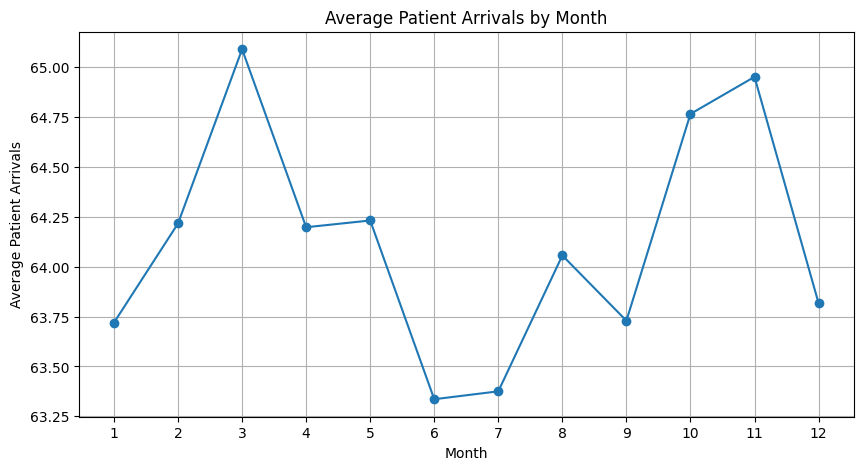

In [24]:
import matplotlib.pyplot as plt

monthly_demand = (
    df.groupby("Month")["Total_Patient_Arrivals"]
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average Patient Arrivals by Month")
plt.xlabel("Month")
plt.ylabel("Average Patient Arrivals")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

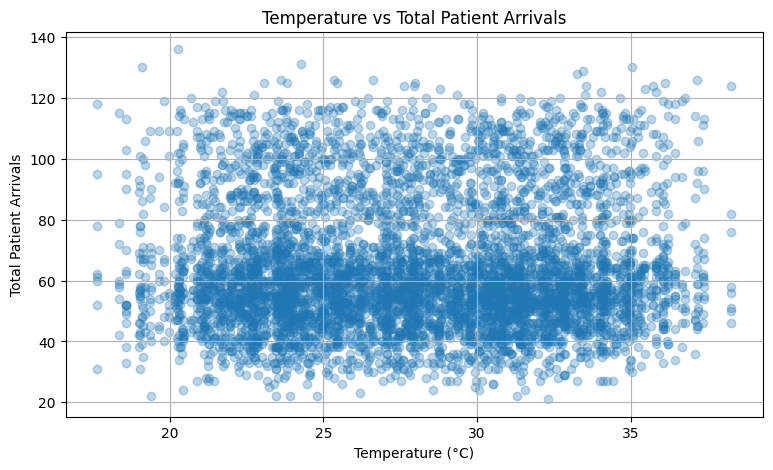

In [25]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Temperature"],
    df["Total_Patient_Arrivals"],
    alpha=0.3
)

plt.title("Temperature vs Total Patient Arrivals")
plt.xlabel("Temperature (°C)")
plt.ylabel("Total Patient Arrivals")

plt.grid(True)

plt.show()

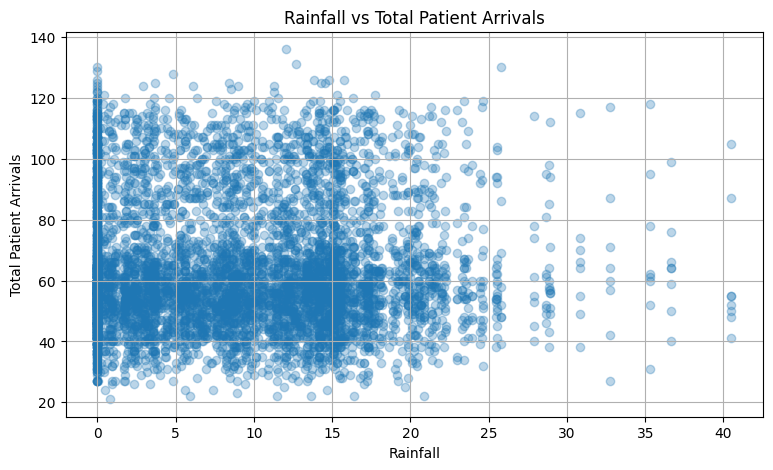

In [26]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Rainfall"],
    df["Total_Patient_Arrivals"],
    alpha=0.3
)

plt.title("Rainfall vs Total Patient Arrivals")
plt.xlabel("Rainfall")
plt.ylabel("Total Patient Arrivals")

plt.grid(True)

plt.show()

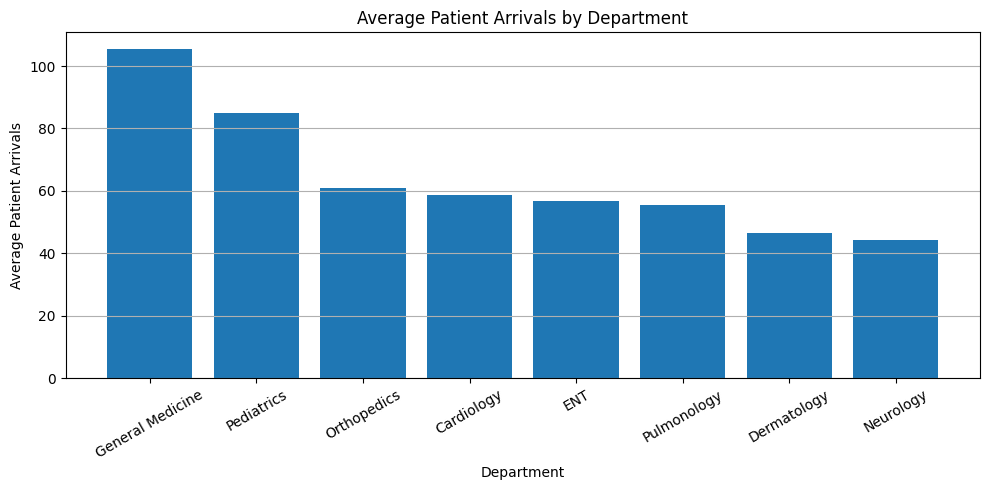

In [27]:
department_demand = (
    df.groupby("Department")["Total_Patient_Arrivals"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

plt.bar(
    department_demand.index,
    department_demand.values
)

plt.title("Average Patient Arrivals by Department")
plt.xlabel("Department")
plt.ylabel("Average Patient Arrivals")

plt.xticks(rotation=30)
plt.grid(axis="y")

plt.tight_layout()
plt.show()

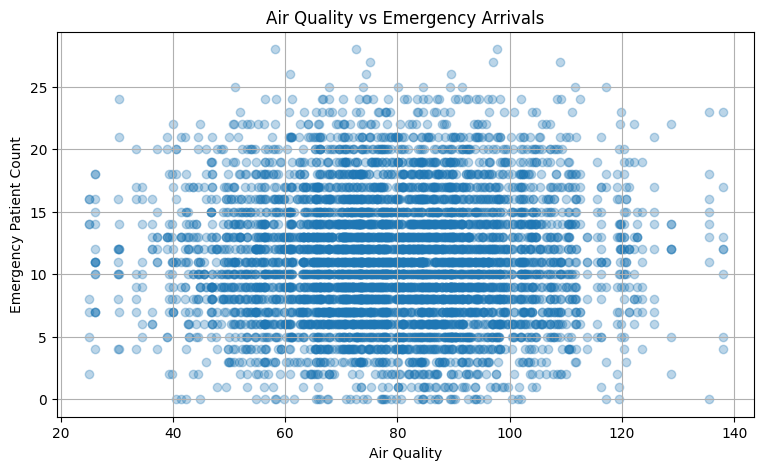

In [28]:
plt.figure(figsize=(9, 5))

plt.scatter(
    df["Air_Quality"],
    df["Emergency_Count"],
    alpha=0.3
)

plt.title("Air Quality vs Emergency Arrivals")
plt.xlabel("Air Quality")
plt.ylabel("Emergency Patient Count")

plt.grid(True)

plt.show()

In [29]:
# STEP 5: SEASONAL AND WEATHER ANALYSIS

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Post-Monsoon"

df["Season"] = df["Month"].apply(get_season)

print(df[["Date", "Month", "Season"]].head())

        Date  Month  Season
0 2024-01-01      1  Winter
1 2024-01-01      1  Winter
2 2024-01-01      1  Winter
3 2024-01-01      1  Winter
4 2024-01-01      1  Winter


In [30]:
season_demand = (
    df.groupby("Season")[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals"
        ]
    ]
    .mean()
)

print("=== PATIENT ARRIVALS BY SEASON ===")
print(season_demand.round(2))

=== PATIENT ARRIVALS BY SEASON ===
              Outpatient_Count  Emergency_Count  Total_Patient_Arrivals
Season                                                                 
Monsoon                  52.56            11.07                   63.63
Post-Monsoon             53.68            11.18                   64.86
Summer                   53.25            11.26                   64.51
Winter                   52.85            11.06                   63.91


In [31]:
highest_season = (
    season_demand["Total_Patient_Arrivals"]
    .idxmax()
)

highest_value = (
    season_demand["Total_Patient_Arrivals"]
    .max()
)

print("Highest patient-arrival season:", highest_season)
print("Average arrivals:", round(highest_value, 2))

Highest patient-arrival season: Post-Monsoon
Average arrivals: 64.86


In [32]:
df["Rainfall_Condition"] = pd.cut(
    df["Rainfall"],
    bins=[-1, 0, 10, float("inf")],
    labels=["No Rain", "Light Rain", "Heavy Rain"]
)

print(
    df["Rainfall_Condition"].value_counts()
)

Rainfall_Condition
Heavy Rain    2592
Light Rain    2352
No Rain        896
Name: count, dtype: int64


In [33]:
rainfall_patients = (
    df.groupby("Rainfall_Condition",
              observed=True)[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals"
        ]
    ]
    .mean()
)

print("=== PATIENT ARRIVALS BY RAINFALL CONDITION ===")
print(rainfall_patients.round(2))

=== PATIENT ARRIVALS BY RAINFALL CONDITION ===
                    Outpatient_Count  Emergency_Count  Total_Patient_Arrivals
Rainfall_Condition                                                           
No Rain                        52.99            11.32                   64.30
Light Rain                     52.88            11.03                   63.91
Heavy Rain                     53.10            11.16                   64.25


In [34]:
df["Temperature_Condition"] = pd.cut(
    df["Temperature"],
    bins=[-float("inf"), 25, 30, float("inf")],
    labels=["Cool", "Moderate", "Hot"]
)

print(
    df["Temperature_Condition"].value_counts()
)

Temperature_Condition
Hot         2192
Cool        1840
Moderate    1808
Name: count, dtype: int64


In [35]:
temperature_patients = (
    df.groupby(
        "Temperature_Condition",
        observed=True
    )[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals"
        ]
    ]
    .mean()
)

print("=== PATIENT ARRIVALS BY TEMPERATURE ===")
print(temperature_patients.round(2))

=== PATIENT ARRIVALS BY TEMPERATURE ===
                       Outpatient_Count  Emergency_Count  \
Temperature_Condition                                      
Cool                              53.02            11.16   
Moderate                          52.73            10.96   
Hot                               53.19            11.25   

                       Total_Patient_Arrivals  
Temperature_Condition                          
Cool                                    64.17  
Moderate                                63.69  
Hot                                     64.44  


In [36]:
df["Air_Quality_Condition"] = pd.qcut(
    df["Air_Quality"],
    q=3,
    labels=[
        "Better Air Quality",
        "Moderate Air Quality",
        "Poorer Air Quality"
    ]
)

print(
    df["Air_Quality_Condition"].value_counts()
)

Air_Quality_Condition
Better Air Quality      1960
Poorer Air Quality      1944
Moderate Air Quality    1936
Name: count, dtype: int64


In [37]:
air_patients = (
    df.groupby(
        "Air_Quality_Condition",
        observed=True
    )[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals"
        ]
    ]
    .mean()
)

print("=== PATIENT ARRIVALS BY AIR QUALITY ===")
print(air_patients.round(2))

=== PATIENT ARRIVALS BY AIR QUALITY ===
                       Outpatient_Count  Emergency_Count  \
Air_Quality_Condition                                      
Better Air Quality                52.94            11.09   
Moderate Air Quality              52.86            11.11   
Poorer Air Quality                53.18            11.19   

                       Total_Patient_Arrivals  
Air_Quality_Condition                          
Better Air Quality                      64.03  
Moderate Air Quality                    63.97  
Poorer Air Quality                      64.37  


In [38]:
print("=== EMERGENCY ARRIVALS BY WEATHER ===")

print(
    df.groupby(
        "Rainfall_Condition",
        observed=True
    )["Emergency_Count"]
    .mean()
    .round(2)
)

=== EMERGENCY ARRIVALS BY WEATHER ===
Rainfall_Condition
No Rain       11.32
Light Rain    11.03
Heavy Rain    11.16
Name: Emergency_Count, dtype: float64


In [39]:
print(
    df.groupby(
        "Temperature_Condition",
        observed=True
    )["Emergency_Count"]
    .mean()
    .round(2)
)

Temperature_Condition
Cool        11.16
Moderate    10.96
Hot         11.25
Name: Emergency_Count, dtype: float64


In [40]:
season_emergency = (
    df.groupby("Season")["Emergency_Count"]
    .mean()
    .sort_values(ascending=False)
)

print("=== AVERAGE EMERGENCY ARRIVALS BY SEASON ===")
print(season_emergency.round(2))

=== AVERAGE EMERGENCY ARRIVALS BY SEASON ===
Season
Summer          11.26
Post-Monsoon    11.18
Monsoon         11.07
Winter          11.06
Name: Emergency_Count, dtype: float64


In [41]:
# STEP 6: DEPARTMENT-WISE WEATHER ANALYSIS

department_summary = (
    df.groupby("Department")[
        [
            "Outpatient_Count",
            "Emergency_Count",
            "Total_Patient_Arrivals"
        ]
    ]
    .mean()
    .sort_values(
        "Total_Patient_Arrivals",
        ascending=False
    )
)

print("=== DEPARTMENT SUMMARY ===")
print(department_summary.round(2))

=== DEPARTMENT SUMMARY ===
                  Outpatient_Count  Emergency_Count  Total_Patient_Arrivals
Department                                                                 
General Medicine             86.74            18.81                  105.55
Pediatrics                   70.73            14.33                   85.06
Orthopedics                  50.75            10.29                   61.04
Cardiology                   46.30            12.34                   58.64
ENT                          49.24             7.50                   56.74
Pulmonology                  43.56            11.92                   55.48
Dermatology                  40.87             5.48                   46.35
Neurology                    35.75             8.38                   44.14


In [42]:
temperature_department = (
    df.groupby("Department")
    .apply(
        lambda x: x["Temperature"].corr(
            x["Total_Patient_Arrivals"]
        ),
        include_groups=False
    )
    .sort_values(
        ascending=False
    )
)

print("=== TEMPERATURE CORRELATION BY DEPARTMENT ===")
print(temperature_department.round(3))

=== TEMPERATURE CORRELATION BY DEPARTMENT ===
Department
General Medicine    0.092
Pediatrics          0.073
Dermatology         0.069
Orthopedics         0.066
Cardiology          0.066
Neurology           0.026
ENT                -0.068
Pulmonology        -0.080
dtype: float64


In [43]:
rainfall_department = (
    df.groupby("Department")
    .apply(
        lambda x: x["Rainfall"].corr(
            x["Total_Patient_Arrivals"]
        ),
        include_groups=False
    )
    .sort_values(
        ascending=False
    )
)

print("=== RAINFALL CORRELATION BY DEPARTMENT ===")
print(rainfall_department.round(3))

=== RAINFALL CORRELATION BY DEPARTMENT ===
Department
ENT                 0.152
Pulmonology         0.117
Dermatology         0.019
Cardiology         -0.007
General Medicine   -0.022
Pediatrics         -0.026
Orthopedics        -0.029
Neurology          -0.036
dtype: float64


In [44]:
humidity_department = (
    df.groupby("Department")
    .apply(
        lambda x: x["Humidity"].corr(
            x["Total_Patient_Arrivals"]
        ),
        include_groups=False
    )
    .sort_values(
        ascending=False
    )
)

print("=== HUMIDITY CORRELATION BY DEPARTMENT ===")
print(humidity_department.round(3))

=== HUMIDITY CORRELATION BY DEPARTMENT ===
Department
ENT                 0.137
Pulmonology         0.092
Neurology           0.012
Pediatrics          0.001
Cardiology         -0.037
Orthopedics        -0.038
Dermatology        -0.053
General Medicine   -0.078
dtype: float64


In [45]:
air_quality_department = (
    df.groupby("Department")
    .apply(
        lambda x: x["Air_Quality"].corr(
            x["Total_Patient_Arrivals"]
        ),
        include_groups=False
    )
    .sort_values(
        ascending=False
    )
)

print("=== AIR QUALITY CORRELATION BY DEPARTMENT ===")
print(air_quality_department.round(3))

=== AIR QUALITY CORRELATION BY DEPARTMENT ===
Department
Pulmonology         0.167
Cardiology          0.055
Pediatrics          0.036
General Medicine    0.027
Orthopedics         0.010
ENT                -0.008
Neurology          -0.037
Dermatology        -0.053
dtype: float64


In [46]:
department_weather_effect = pd.DataFrame({
    "Temperature": temperature_department,
    "Rainfall": rainfall_department,
    "Humidity": humidity_department,
    "Air_Quality": air_quality_department
})

print("=== DEPARTMENT-WISE WEATHER EFFECT ===")
print(department_weather_effect.round(3))

=== DEPARTMENT-WISE WEATHER EFFECT ===
                  Temperature  Rainfall  Humidity  Air_Quality
Department                                                    
Cardiology              0.066    -0.007    -0.037        0.055
Dermatology             0.069     0.019    -0.053       -0.053
ENT                    -0.068     0.152     0.137       -0.008
General Medicine        0.092    -0.022    -0.078        0.027
Neurology               0.026    -0.036     0.012       -0.037
Orthopedics             0.066    -0.029    -0.038        0.010
Pediatrics              0.073    -0.026     0.001        0.036
Pulmonology            -0.080     0.117     0.092        0.167


In [47]:
absolute_effect = department_weather_effect.abs()

strongest_effect = absolute_effect.max(axis=1)

print("=== STRONGEST WEATHER EFFECT BY DEPARTMENT ===")
print(strongest_effect.sort_values(ascending=False).round(3))

=== STRONGEST WEATHER EFFECT BY DEPARTMENT ===
Department
Pulmonology         0.167
ENT                 0.152
General Medicine    0.092
Pediatrics          0.073
Dermatology         0.069
Orthopedics         0.066
Cardiology          0.066
Neurology           0.037
dtype: float64


In [48]:
most_affected_department = strongest_effect.idxmax()

strongest_correlation = strongest_effect.max()

print(
    "Department with strongest weather relationship:",
    most_affected_department
)

print(
    "Correlation strength:",
    round(strongest_correlation, 3)
)

Department with strongest weather relationship: Pulmonology
Correlation strength: 0.167


In [49]:
emergency_weather = {}

for department in df["Department"].unique():

    temp_corr = df[
        df["Department"] == department
    ]["Temperature"].corr(
        df[
            df["Department"] == department
        ]["Emergency_Count"]
    )

    rain_corr = df[
        df["Department"] == department
    ]["Rainfall"].corr(
        df[
            df["Department"] == department
        ]["Emergency_Count"]
    )

    emergency_weather[department] = {
        "Temperature": temp_corr,
        "Rainfall": rain_corr
    }

emergency_weather_df = pd.DataFrame(
    emergency_weather
).T

print("=== EMERGENCY WEATHER EFFECT ===")
print(emergency_weather_df.round(3))

=== EMERGENCY WEATHER EFFECT ===
                  Temperature  Rainfall
General Medicine        0.103    -0.043
Cardiology              0.115    -0.062
Pediatrics              0.048    -0.023
Orthopedics             0.008     0.041
Dermatology             0.041     0.011
ENT                    -0.063     0.116
Neurology               0.030    -0.012
Pulmonology            -0.057     0.036


In [50]:
# STEP 7: WEATHER-PATIENT RELATIONSHIP

weather_columns = [
    "Temperature",
    "Rainfall",
    "Humidity",
    "Air_Quality"
]

correlation = df[
    weather_columns + ["Total_Patient_Arrivals"]
].corr()

print("=== WEATHER VS TOTAL PATIENT ARRIVALS ===")
print(
    correlation["Total_Patient_Arrivals"]
    .sort_values(ascending=False)
    .round(3)
)

=== WEATHER VS TOTAL PATIENT ARRIVALS ===
Total_Patient_Arrivals    1.000
Temperature               0.012
Air_Quality               0.010
Rainfall                  0.009
Humidity                  0.002
Name: Total_Patient_Arrivals, dtype: float64


In [51]:
weather_correlation = (
    correlation["Total_Patient_Arrivals"]
    .drop("Total_Patient_Arrivals")
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("=== WEATHER CORRELATIONS ===")
print(weather_correlation.round(3))

=== WEATHER CORRELATIONS ===
Temperature    0.012
Air_Quality    0.010
Rainfall       0.009
Humidity       0.002
Name: Total_Patient_Arrivals, dtype: float64


In [52]:
emergency_corr = df[
    weather_columns + ["Emergency_Count"]
].corr()

print("=== WEATHER VS EMERGENCY ARRIVALS ===")

print(
    emergency_corr["Emergency_Count"]
    .drop("Emergency_Count")
    .sort_values(
        key=abs,
        ascending=False
    )
    .round(3)
)

=== WEATHER VS EMERGENCY ARRIVALS ===
Temperature    0.017
Air_Quality    0.016
Rainfall       0.005
Humidity      -0.005
Name: Emergency_Count, dtype: float64


In [53]:
X = df[
    [
        "Temperature",
        "Rainfall",
        "Humidity",
        "Air_Quality"
    ]
]

y = df["Total_Patient_Arrivals"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5840, 4)
y shape: (5840,)


In [54]:
split = int(len(df) * 0.80)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 4672
Testing records: 1168


In [55]:
from sklearn.linear_model import LinearRegression

In [56]:
model = LinearRegression()

In [57]:
model.fit(
    X_train,
    y_train
)

print("Linear Regression model training completed!")

Linear Regression model training completed!


In [58]:
y_pred = model.predict(X_test)

print("Predictions created!")
print(y_pred[:10])


Predictions created!
[63.28458426 63.28458426 63.28458426 63.28458426 63.28458426 63.28458426
 63.28458426 63.28458426 63.87269623 63.87269623]


In [59]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

       Feature  Coefficient
0  Temperature     0.291219
1     Rainfall     0.127240
2     Humidity     0.015939
3  Air_Quality     0.012088


In [60]:
print("Intercept:", model.intercept_)

Intercept: 52.63050873414264


In [61]:
# STEP 8: MODEL EVALUATION

import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [62]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", round(mae, 2))

MAE: 16.65


In [63]:
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

print("RMSE:", round(rmse, 2))

RMSE: 21.38


In [64]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R²:", round(r2, 4))

R²: -0.002


In [65]:
mape = np.mean(
    np.abs(
        (y_test - y_pred) / y_test
    )
) * 100

print("MAPE:", round(mape, 2), "%")

MAPE: 27.59 %


In [66]:
print("=== LINEAR REGRESSION MODEL RESULTS ===")

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))
print("MAPE:", round(mape, 2), "%")

=== LINEAR REGRESSION MODEL RESULTS ===
MAE : 16.65
RMSE: 21.38
R²  : -0.002
MAPE: 27.59 %


In [67]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison.head(10))

   Actual  Predicted
0     106  63.284584
1      58  63.284584
2      79  63.284584
3      39  63.284584
4      47  63.284584
5      38  63.284584
6      55  63.284584
7      71  63.284584
8      67  63.872696
9      48  63.872696


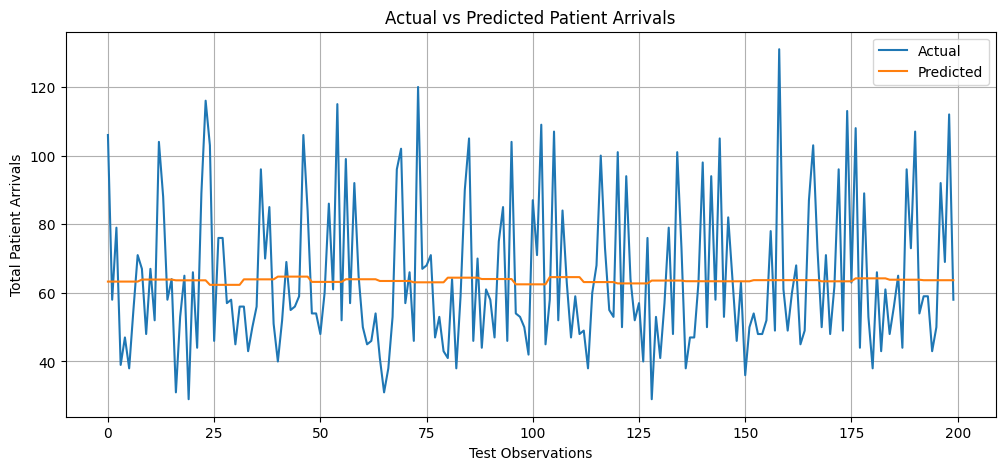

In [68]:
plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values[:200],
    label="Actual"
)

plt.plot(
    y_pred[:200],
    label="Predicted"
)

plt.title(
    "Actual vs Predicted Patient Arrivals"
)

plt.xlabel("Test Observations")
plt.ylabel("Total Patient Arrivals")

plt.legend()
plt.grid(True)

plt.show()

In [69]:
prediction_df = pd.DataFrame({
    "Actual_Patient_Arrivals": y_test.values,
    "Predicted_Patient_Arrivals": y_pred
})

prediction_df.to_csv(
    "linear_regression_predictions.csv",
    index=False
)

print("Predictions saved successfully!")

Predictions saved successfully!


In [70]:
import joblib

joblib.dump(
    model,
    "hospital_weather_linear_regression.pkl"
)

print("Model saved successfully!")

Model saved successfully!


In [71]:
# STEP 9: FINAL KEY INSIGHTS

print("=== FINAL PROJECT RESULTS ===")

# 1. Highest patient-arrival department
highest_department = (
    df.groupby("Department")["Total_Patient_Arrivals"]
    .mean()
    .idxmax()
)

highest_department_value = (
    df.groupby("Department")["Total_Patient_Arrivals"]
    .mean()
    .max()
)

print("\n1. Highest average department:")
print(highest_department)
print("Average arrivals:", round(highest_department_value, 2))

# 2. Highest-demand season
season_avg = (
    df.groupby("Season")["Total_Patient_Arrivals"]
    .mean()
)

print("\n2. Average arrivals by season:")
print(season_avg.round(2))

# 3. Highest rainfall condition
rain_avg = (
    df.groupby(
        "Rainfall_Condition",
        observed=True
    )["Total_Patient_Arrivals"]
    .mean()
)

print("\n3. Average arrivals by rainfall:")
print(rain_avg.round(2))

# 4. Temperature relationship
temp_corr = df[
    "Temperature"
].corr(
    df["Total_Patient_Arrivals"]
)

print("\n4. Temperature correlation:")
print(round(temp_corr, 3))

# 5. Rainfall relationship
rain_corr = df[
    "Rainfall"
].corr(
    df["Total_Patient_Arrivals"]
)

print("\n5. Rainfall correlation:")
print(round(rain_corr, 3))

# 6. Humidity relationship
humidity_corr = df[
    "Humidity"
].corr(
    df["Total_Patient_Arrivals"]
)

print("\n6. Humidity correlation:")
print(round(humidity_corr, 3))

# 7. Air quality relationship
air_corr = df[
    "Air_Quality"
].corr(
    df["Total_Patient_Arrivals"]
)

print("\n7. Air Quality correlation:")
print(round(air_corr, 3))

=== FINAL PROJECT RESULTS ===

1. Highest average department:
General Medicine
Average arrivals: 105.55

2. Average arrivals by season:
Season
Monsoon         63.63
Post-Monsoon    64.86
Summer          64.51
Winter          63.91
Name: Total_Patient_Arrivals, dtype: float64

3. Average arrivals by rainfall:
Rainfall_Condition
No Rain       64.30
Light Rain    63.91
Heavy Rain    64.25
Name: Total_Patient_Arrivals, dtype: float64

4. Temperature correlation:
0.012

5. Rainfall correlation:
0.009

6. Humidity correlation:
0.002

7. Air Quality correlation:
0.01


Final 7 Insights — Report Format

After running the code, write your results in this format.

Insight 1 — Seasonal variation

Patient arrivals vary across different seasons. The season with the highest average patient arrivals can be identified from the seasonal analysis.

Insight 2 — Department differences

Patient volume differs between hospital departments. The department with the highest average patient arrivals can require greater staffing and resource planning.

Insight 3 — Temperature relationship

Temperature shows a statistical relationship with total patient arrivals. The correlation value indicates the direction and strength of this relationship.

Insight 4 — Rainfall relationship

Rainfall can be compared with patient arrivals to determine whether rainy conditions are associated with changes in hospital attendance.

Insight 5 — Humidity relationship

Humidity can also influence patient patterns. The correlation analysis indicates whether higher or lower humidity is associated with changes in arrivals.

Insight 6 — Air quality and emergency arrivals

Air quality should be examined particularly for emergency arrivals, because changes in air conditions may be associated with certain emergency visits.

Insight 7 — Overall weather hypothesis

The combination of correlation analysis, weather-condition comparisons, and Linear Regression provides evidence about whether weather variables are statistically associated with patient arrivals.

Important: A statistical association does not by itself prove that weather causes patient arrivals to change.

Practical Action Plan

1. Staff planning

The hospital can use seasonal and daily patient-arrival patterns to plan staffing levels.

2. Emergency preparedness

If particular weather conditions are associated with higher emergency arrivals, the hospital can prepare additional emergency resources during those periods.

3. Department resource allocation

Departments showing stronger weather-related relationships can receive additional monitoring and appropriate resource planning.

4. Weather monitoring

The hospital can monitor weather forecasts alongside expected patient arrivals.

5. Seasonal planning

Historical seasonal patterns can help the hospital prepare medicines, beds, staff and other resources ahead of high-demand periods.

6. Air-quality monitoring

If the analysis shows an association between air quality and emergency arrivals, air-quality information can be included in hospital planning.

7. Forecasting support

The Linear Regression model can provide an initial estimate of patient arrivals based on weather variables. The model should be updated with additional relevant factors for operational use.

Conclusion:
This project analyzed two years of hospital patient-arrival and weather data to investigate whether weather conditions are associated with changes in patient arrivals. The analysis examined seasonal patterns, temperature, rainfall, humidity, air quality and department-level patient volumes. Correlation analysis and Linear Regression were used to quantify the relationship between weather variables and total patient arrivals. The results provide statistical evidence about the strength of these relationships, while recognizing that correlation does not prove causation. The findings can help hospital management with staffing, emergency preparedness, resource allocation and seasonal planning.